# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

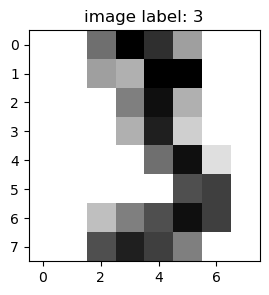

In [2]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [3]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [4]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [5]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [6]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [7]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [8]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [9]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [10]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [13]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [14]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [15]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [16]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [17]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [19]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        self.W = np.random.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Compute the linear combination of the input and weights
        Z = np.dot(X, self.W) + self.b
        # Apply softmax
        return softmax(Z)
    
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        y_onehot = one_hot(self.output_size, y.astype(int))
        Y_pred = self.forward(X)
        return nll(y_onehot, Y_pred)

    def grad_loss(self, X, y_true, y_pred):
        grad_W = np.dot(X.T, (y_pred - y_true))
        grad_b = np.sum(y_pred - y_true, axis=0)
        return grad_W, grad_b

# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [20]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

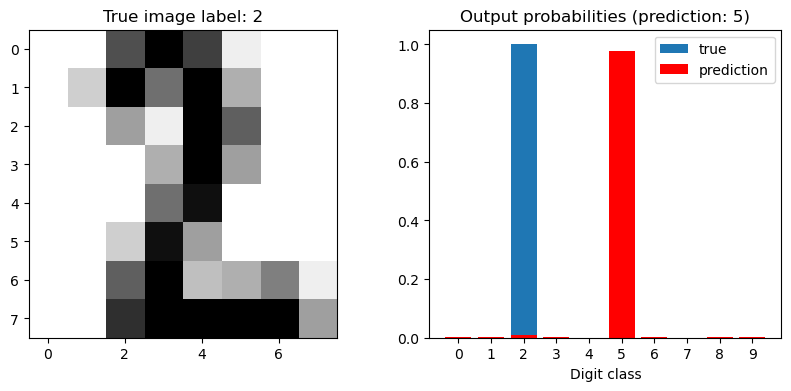

In [21]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [22]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 100: 149
Average NLL over the last 100 samples at step 200: 213
Average NLL over the last 100 samples at step 300: 408
Average NLL over the last 100 samples at step 400: 141
Average NLL over the last 100 samples at step 500: 149
Average NLL over the last 100 samples at step 600: 86
Average NLL over the last 100 samples at step 700: 118
Average NLL over the last 100 samples at step 800: 77
Average NLL over the last 100 samples at step 900: 121
Average NLL over the last 100 samples at step 1000: 452
Average NLL over the last 100 samples at step 1100: 408
Average NLL over the last 100 samples at step 1200: 52
Average NLL over the last 100 samples at step 1300: 145
Average NLL over the last 100 samples at step 1400: 190
Average NLL over the last 100 samples at step 1500: 85


Evaluate the trained model on the first example:

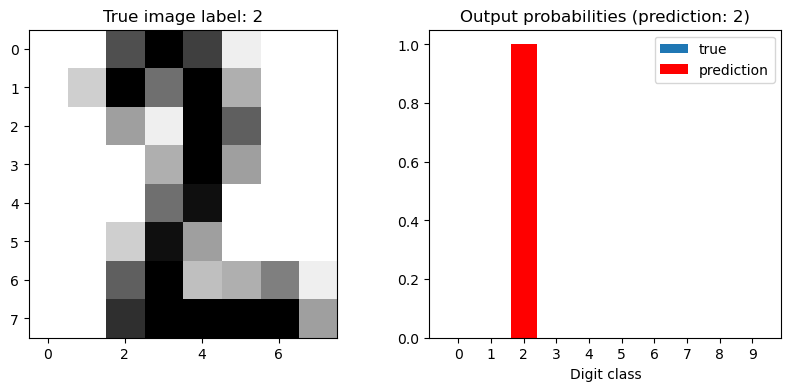

In [23]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

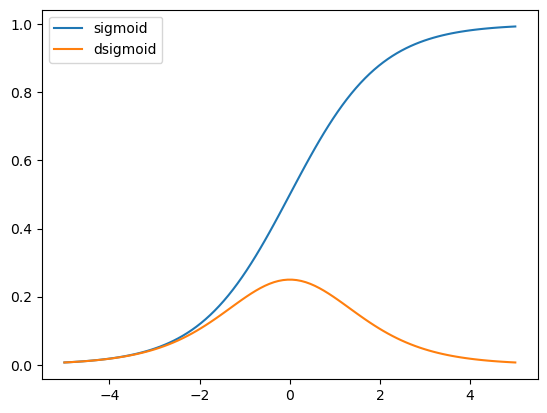

In [25]:
def sigmoid(X):
    X = np.clip(X, -500, 500)
    return 1.0 / (1.0 + np.exp(-X))

def dsigmoid(X):
    s = sigmoid(X)
    return s * (1 - s)


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [27]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        self.Z_h = np.dot(X, self.W_h) + self.b_h
        return sigmoid(self.Z_h)

    def forward_output(self, H):
        self.Z_o = np.dot(H, self.W_o) + self.b_o
        return softmax(self.Z_o)

    def forward(self, X):
        H = self.forward_hidden(X)
        Y = self.forward_output(H)
        return Y

    def loss(self, X, y):
        y = y.astype(int)
        y_onehot = one_hot(self.output_size, y)
        Y_pred = self.forward(X)
        return nll(y_onehot, Y_pred)

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        error_o = y_pred - y_true
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        x = x[np.newaxis, :]
        grads = self.grad_loss(x, y)
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [28]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [29]:
model.loss(X_train, y_train)

np.float64(3524.2627205833783)

In [30]:
model.accuracy(X_train, y_train)

np.float64(0.10150622134905042)

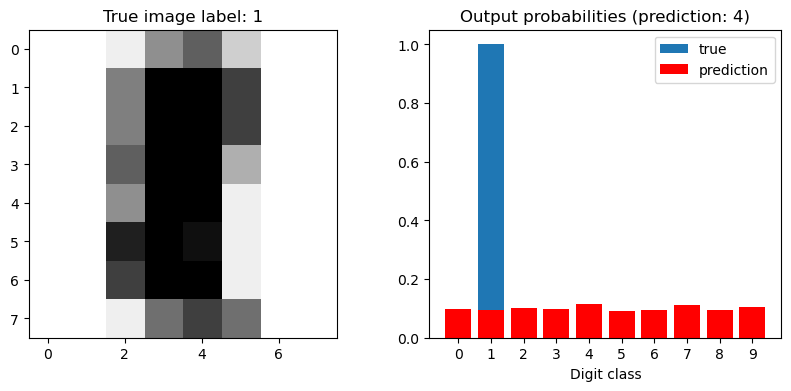

In [31]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [32]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 3524.26272, train acc: 0.102, test acc: 0.089
Epoch #1, train loss: 2833.53495, train acc: 0.506, test acc: 0.507
Epoch #2, train loss: 1956.14855, train acc: 0.755, test acc: 0.719
Epoch #3, train loss: 1353.58436, train acc: 0.843, test acc: 0.800
Epoch #4, train loss: 1009.17992, train acc: 0.880, test acc: 0.878
Epoch #5, train loss: 818.67143, train acc: 0.901, test acc: 0.904
Epoch #6, train loss: 684.49624, train acc: 0.920, test acc: 0.911
Epoch #7, train loss: 590.75216, train acc: 0.927, test acc: 0.911
Epoch #8, train loss: 519.47651, train acc: 0.935, test acc: 0.919
Epoch #9, train loss: 460.68246, train acc: 0.942, test acc: 0.930
Epoch #10, train loss: 412.09469, train acc: 0.948, test acc: 0.926
Epoch #11, train loss: 372.85680, train acc: 0.951, test acc: 0.922
Epoch #12, train loss: 340.72884, train acc: 0.954, test acc: 0.933
Epoch #13, train loss: 314.38539, train acc: 0.960, test acc: 0.930
Epoch #14, train loss: 292.47808, train acc: 0.965

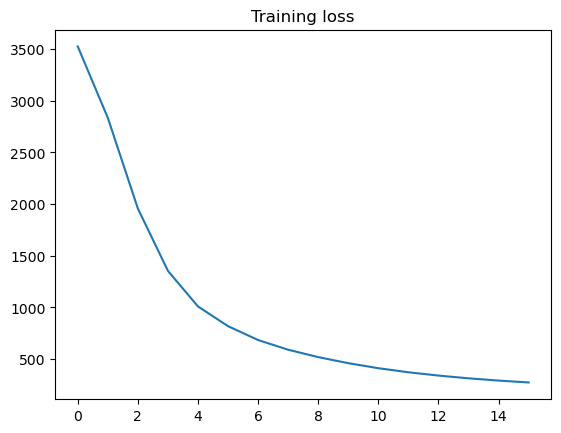

In [33]:
plt.plot(losses)
plt.title("Training loss");

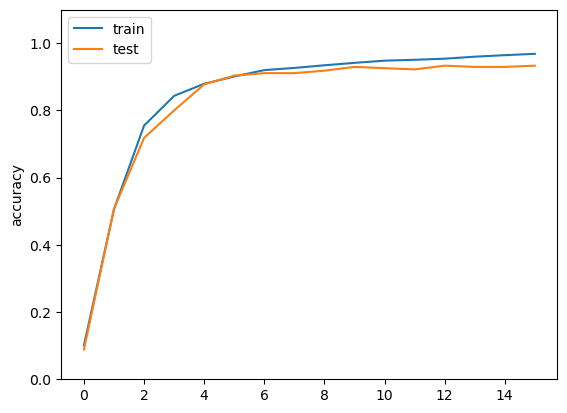

In [34]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

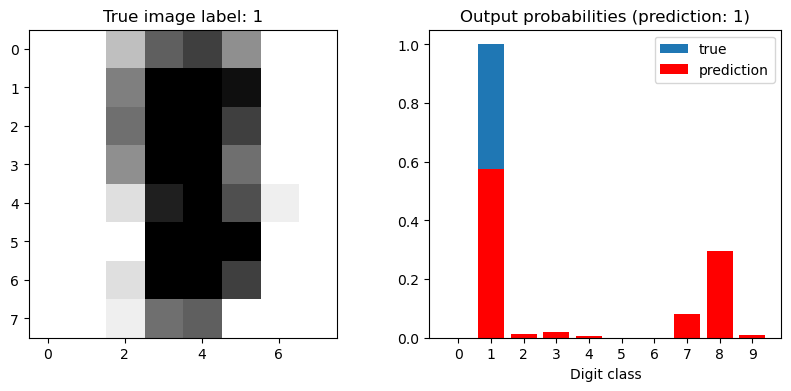

In [35]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

Worst predictions:
Sample 107: true label = 5, predicted = 9, loss = 5.4120


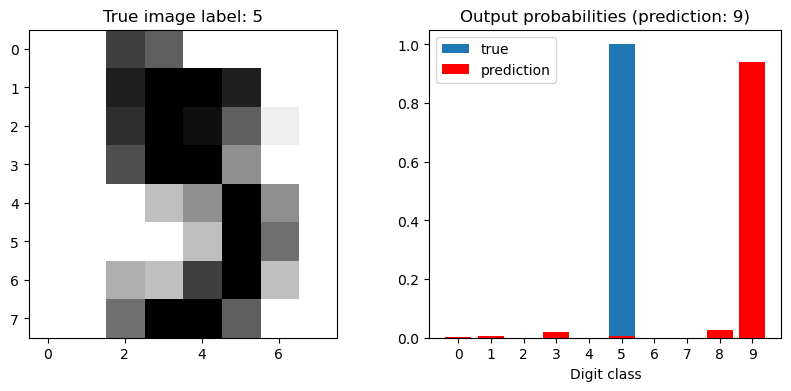

Sample 69: true label = 8, predicted = 9, loss = 3.4148


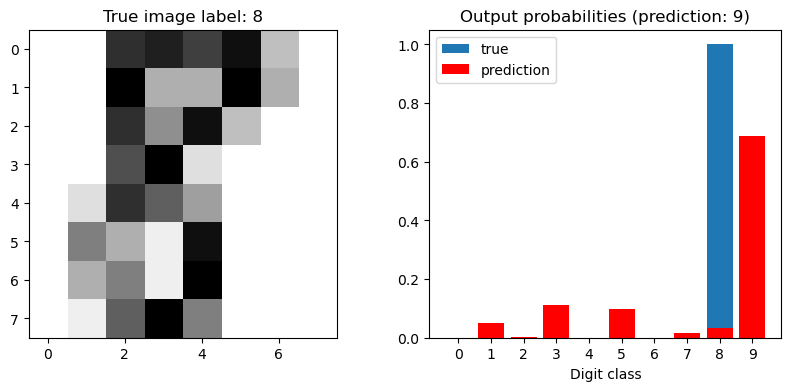

Sample 170: true label = 5, predicted = 9, loss = 3.0062


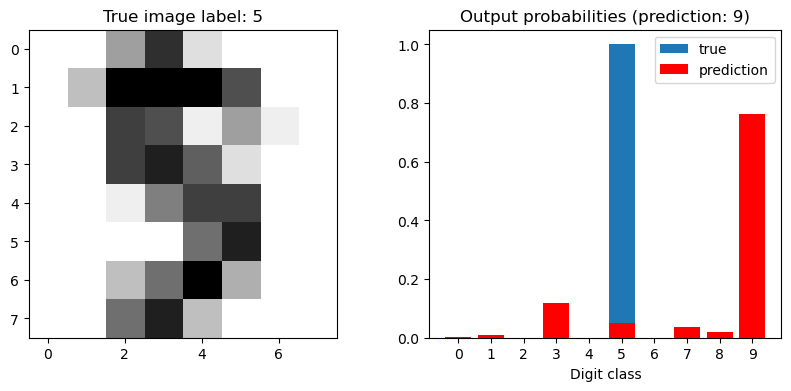

Sample 99: true label = 4, predicted = 1, loss = 2.9052


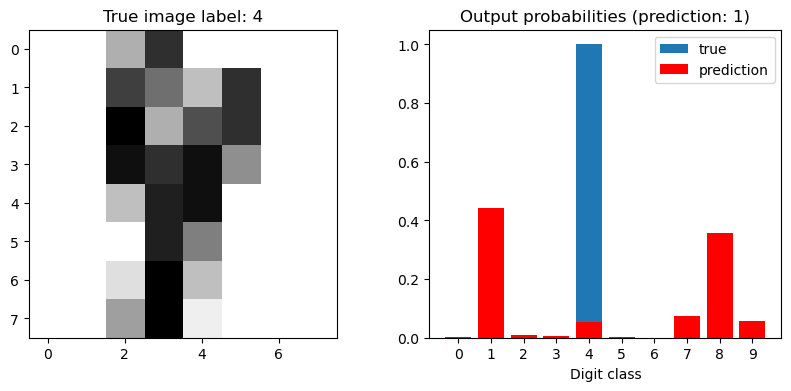

Sample 212: true label = 0, predicted = 4, loss = 2.7696


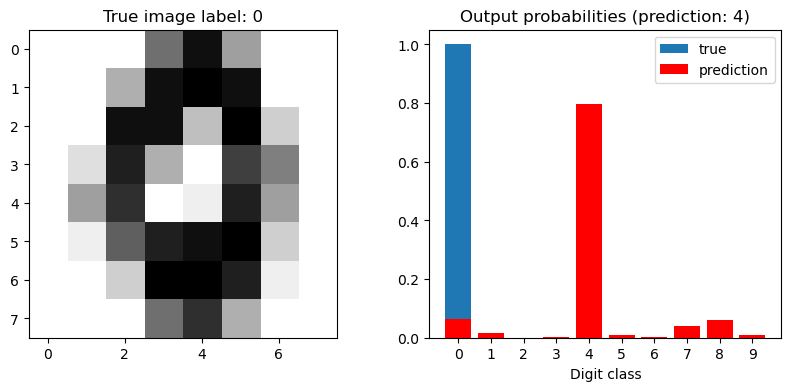

In [36]:
# Find test samples with worst predictions
test_predictions = model.predict(X_test)
wrong_predictions = np.where(test_predictions != y_test)[0]

# Calculate loss for each wrong prediction
wrong_losses = []
for idx in wrong_predictions:
    loss = model.loss(X_test[idx:idx+1], y_test[idx:idx+1])
    wrong_losses.append((idx, loss))

# Sort by loss (highest first)
wrong_losses.sort(key=lambda x: x[1], reverse=True)

# Plot the worst predictions
print("Worst predictions:")
for i, (idx, loss) in enumerate(wrong_losses[:5]):
    print(f"Sample {idx}: true label = {y_test[idx]}, predicted = {test_predictions[idx]}, loss = {loss:.4f}")
    plot_prediction(model, sample_idx=idx)
    plt.show()

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [37]:
# Experiment with different hyperparameters
def train_and_evaluate(hidden_size, learning_rate, epochs=15):
    model = NeuralNet(n_features, hidden_size, n_classes)
    
    losses, accuracies, accuracies_test = [], [], []
    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    
    print(f"Training with hidden_size={hidden_size}, learning_rate={learning_rate}")
    print(f"Random init: train loss: {losses[-1]:0.5f}, train acc: {accuracies[-1]:0.3f}, test acc: {accuracies_test[-1]:0.3f}")

    for epoch in range(epochs):
        for i, (x, y) in enumerate(zip(X_train, y_train)):
            model.train(x, y, learning_rate)

        losses.append(model.loss(X_train, y_train))
        accuracies.append(model.accuracy(X_train, y_train))
        accuracies_test.append(model.accuracy(X_test, y_test))
        print(f"Epoch #{epoch + 1}, train loss: {losses[-1]:0.5f}, train acc: {accuracies[-1]:0.3f}, test acc: {accuracies_test[-1]:0.3f}")
    
    return model, accuracies_test[-1]

# Test different hyperparameters
best_accuracy = 0
best_params = {}

for hidden_size in [10, 20, 50]:
    for learning_rate in [0.001, 0.01, 0.1]:
        model, test_acc = train_and_evaluate(hidden_size, learning_rate, epochs=10)
        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_params = {'hidden_size': hidden_size, 'learning_rate': learning_rate}
        print("---")

print(f"Best accuracy: {best_accuracy:.3f}")
print(f"Best parameters: {best_params}")

Training with hidden_size=10, learning_rate=0.001
Random init: train loss: 3527.21905, train acc: 0.099, test acc: 0.100
Epoch #1, train loss: 2661.53295, train acc: 0.626, test acc: 0.604
Epoch #2, train loss: 1861.90367, train acc: 0.776, test acc: 0.741
Epoch #3, train loss: 1311.92576, train acc: 0.870, test acc: 0.837
Epoch #4, train loss: 956.75755, train acc: 0.906, test acc: 0.911
Epoch #5, train loss: 737.71386, train acc: 0.925, test acc: 0.911
Epoch #6, train loss: 603.17854, train acc: 0.942, test acc: 0.926
Epoch #7, train loss: 523.05898, train acc: 0.946, test acc: 0.926
Epoch #8, train loss: 486.40577, train acc: 0.949, test acc: 0.933
Epoch #9, train loss: 543.50040, train acc: 0.936, test acc: 0.911
Epoch #10, train loss: 1012.48360, train acc: 0.764, test acc: 0.744
---
Training with hidden_size=10, learning_rate=0.01
Random init: train loss: 3521.32726, train acc: 0.085, test acc: 0.081
Epoch #1, train loss: 1597.88543, train acc: 0.620, test acc: 0.567
Epoch #2, tr

In [38]:
class NeuralNetTwoLayers():
    """MLP with 2 hidden layers with sigmoid activation"""

    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        self.W_h1 = np.random.uniform(size=(input_size, hidden1_size), high=0.1, low=-0.1)
        self.b_h1 = np.random.uniform(size=hidden1_size, high=0.1, low=-0.1)
        self.W_h2 = np.random.uniform(size=(hidden1_size, hidden2_size), high=0.1, low=-0.1)
        self.b_h2 = np.random.uniform(size=hidden2_size, high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden2_size, output_size), high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size, high=0.1, low=-0.1)
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.output_size = output_size

    def forward_hidden1(self, X):
        self.Z_h1 = np.dot(X, self.W_h1) + self.b_h1
        return sigmoid(self.Z_h1)

    def forward_hidden2(self, H1):
        self.Z_h2 = np.dot(H1, self.W_h2) + self.b_h2
        return sigmoid(self.Z_h2)

    def forward_output(self, H2):
        self.Z_o = np.dot(H2, self.W_o) + self.b_o
        return softmax(self.Z_o)

    def forward(self, X):
        H1 = self.forward_hidden1(X)
        H2 = self.forward_hidden2(H1)
        return self.forward_output(H2)

    def loss(self, X, y):
        y_onehot = one_hot(self.output_size, y.astype(int))
        Y_pred = self.forward(X)
        return nll(y_onehot, Y_pred)

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Output layer gradients
        error_o = y_pred - y_true
        grad_W_o = np.dot(self.Z_h2.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Second hidden layer gradients
        error_h2 = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h2)
        grad_W_h2 = np.dot(self.Z_h1.T, error_h2)
        grad_b_h2 = np.sum(error_h2, axis=0)

        # First hidden layer gradients
        error_h1 = np.dot(error_h2, self.W_h2.T) * dsigmoid(self.Z_h1)
        grad_W_h1 = np.dot(X.T, error_h1)
        grad_b_h1 = np.sum(error_h1, axis=0)

        return {"W_h1": grad_W_h1, "b_h1": grad_b_h1, 
                "W_h2": grad_W_h2, "b_h2": grad_b_h2,
                "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        x = x[np.newaxis, :]
        grads = self.grad_loss(x, y)
        self.W_h1 -= learning_rate * grads["W_h1"]
        self.b_h1 -= learning_rate * grads["b_h1"]
        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)

# Test the two-layer network
print("Testing two-layer network:")
model_2layer = NeuralNetTwoLayers(n_features, 32, 16, n_classes)
test_acc = model_2layer.accuracy(X_test, y_test)
print(f"Initial accuracy: {test_acc:.3f}")

Testing two-layer network:
Initial accuracy: 0.096
